In [2]:
# set auto-reload of the notebook
%load_ext autoreload
%autoreload 2

In [3]:
import cns
import cns.data_utils as cdu
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 10)
# set color_map to tab10
color_map = plt.cm.get_cmap('tab10').colors[:10]
plt.rcParams.update({'font.size': 12})

C:\Users\adams\AppData\Local\Temp/ipykernel_26392/27608293.py:8: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  color_map = plt.cm.get_cmap('tab10').colors[:10]


In [73]:
cancer_type = "all"
cns_scores_df = pd.read_csv(cdu.pjoin(cdu.out_path, f"gene_scores_{cancer_type}.tsv"), sep="\t")
ogs_df = pd.read_csv(cdu.pjoin(cdu.data_path, "ogs.tsv"), sep="\t").rename(columns={"Chromosome": "chrom", "Start": "start", "End": "end", "OG_Probability_LASSO": "OG"})[["chrom", "start", "end", "OG"]]
tsgs_df = pd.read_csv(cdu.pjoin(cdu.data_path, "tsgs.tsv"), sep="\t").rename(columns={"Chromosome": "chrom", "Start": "start", "End": "end", "TSG_Probability_LASSO": "TSG"})[["chrom", "start", "end", "TSG"]]

In [74]:
merge_df = pd.merge(cns_scores_df, ogs_df, on=["chrom", "start", "end"], how="inner")
merge_df = pd.merge(merge_df, tsgs_df, on=["chrom", "start", "end"], how="inner")
merge_df

,chrom,start,end,name,score,total_cn,gene,OG,TSG
0,chr1,69091,70008,ENSG00000186092,0.000000,2.512906,NaN,0.534744,0.142321
1,chr1,860260,879955,ENSG00000187634,0.000610,2.514334,NaN,0.528379,0.039523
2,chr1,879584,894689,ENSG00000188976,0.000610,2.514334,NaN,0.592945,0.015258
3,chr1,895967,901095,ENSG00000187961,0.000610,2.514334,NaN,0.554968,0.128525
4,chr1,901877,911245,ENSG00000187583,0.000610,2.514334,NaN,0.441886,0.121833
...,...,...,...,...,...,...,...,...,...
17670,chr9,140476531,140484942,ENSG00000165724,-0.000785,2.555977,NaN,0.255344,0.409866
17671,chr9,140500106,140509812,ENSG00000197070,-0.000785,2.555977,NaN,0.500750,0.238035
17672,chr9,140509784,140513358,ENSG00000203993,-0.000785,2.555977,NaN,0.425876,0.141044
17673,chr9,140513444,140764468,ENSG00000181090,-0.000432,2.554803,NaN,0.588784,0.024969


In [75]:
z_scores = (merge_df['score'] - merge_df['score'].mean()) / merge_df['score'].std()
filtered_df = merge_df[(z_scores > 3) | (z_scores < -3)]
filtered_df

,chrom,start,end,name,score,total_cn,gene,OG,TSG
3224,chr11,63678693,63684316,ENSG00000167771,0.094771,2.671588,NaN,0.618579,0.186090
3225,chr11,63706431,63724800,ENSG00000110583,0.094771,2.671588,NaN,0.318509,0.295269
3226,chr11,63742079,63744015,ENSG00000176340,0.094771,2.671588,NaN,0.470490,0.087698
3227,chr11,63753325,63769283,ENSG00000167770,0.094771,2.671588,NaN,0.421022,0.152888
3228,chr11,63766030,63933578,ENSG00000133315,0.094994,2.671605,NaN,0.599086,0.023122
...,...,...,...,...,...,...,...,...,...
17028,chr9,21480841,21482312,ENSG00000184995,0.116949,2.234777,NaN,0.444891,0.226029
17029,chr9,21802542,21931646,ENSG00000099810,0.180242,2.173225,NaN,0.464573,0.162886
17030,chr9,21967751,21995300,ENSG00000147889,0.190457,2.134309,CDKN2A,0.295705,0.988742
17031,chr9,22002902,22009362,ENSG00000147883,0.190457,2.134309,NaN,0.507001,0.072330


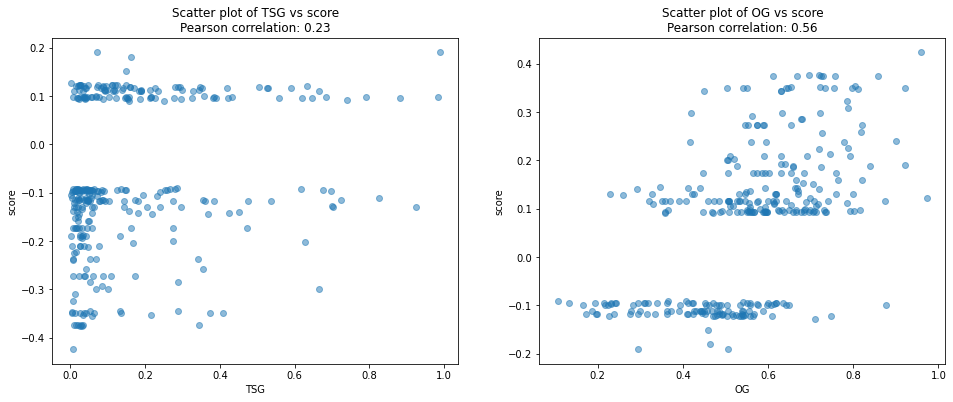

In [76]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for i, label in enumerate(['TSG', 'OG']):
    factor = 1 if label == "TSG" else -1
    sel_df = filtered_df
    corr = sel_df[label].corr(sel_df['score'] * factor, method='pearson')
    axes[i].scatter(sel_df[label], sel_df['score'] * factor, alpha=0.5, color=color_map[0])
    axes[i].set_xlabel(label)
    axes[i].set_ylabel('score')
    axes[i].set_title(f'Scatter plot of {label} vs score\nPearson correlation: {corr:.2f}')


In [49]:
# calculate z-score on sel_df["TSG"]
z_scores = (sel_df['TSG'] - sel_df['TSG'].mean()) / sel_df['TSG'].std()
sel_df[z_scores > 3]

,chrom,start,end,name,score,total_cn,gene,OG,TSG
17030,chr9,21967751,21995300,ENSG00000147889,0.190457,2.134309,CDKN2A,0.295705,0.988742
3255,chr11,64570982,64578766,ENSG00000133895,0.098959,2.674760,MEN1,0.225014,0.982550
7602,chr17,41196312,41277500,ENSG00000012048,0.098524,2.710870,BRCA1,0.165355,0.790358
3230,chr11,63952744,63972015,ENSG00000168439,0.095438,2.671639,NaN,0.132021,0.883180
16521,chr8,38243725,38267045,ENSG00000165046,-0.110432,3.010619,NaN,0.330220,0.825258
4380,chr12,57914493,57923931,ENSG00000166987,-0.129474,3.011436,NaN,0.228652,0.926018
